<a href="https://colab.research.google.com/github/aleesha33/Spam-Email-Analyzer-with-NLP/blob/main/spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/spam.csv", encoding="ISO=8859-1")

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis=1, inplace=True)

In [ ]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isna().sum()

,0
v1,0
v2,0


<Axes: xlabel='count', ylabel='v1'>

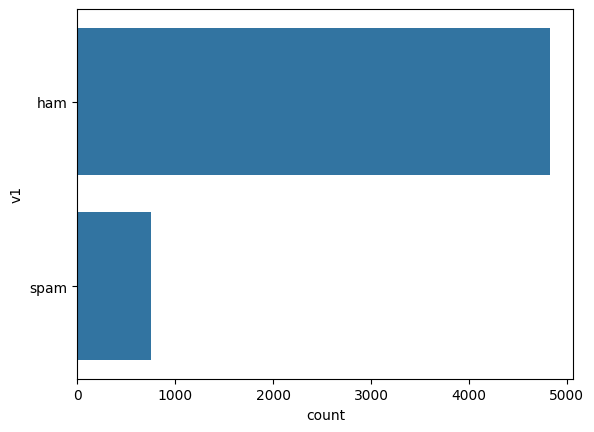

In [ ]:
import seaborn as sns
sns.countplot(df['v1'])

In [ ]:
df['v1']=df['v1'].map({'ham':1, 'spam': 0})

In [ ]:
df['v1']

,v1
0,1
1,1
2,0
3,1
4,1
...,...
5567,0
5568,1
5569,1
5570,1


In [ ]:
df['v2']=df['v2'].replace("[^0-9 a-z A-Z]"," ",regex=True)
df['v2']

,v2
0,Go until jurong point crazy Available only ...
1,Ok lar Joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor U c already then say
4,Nah I don t think he goes to usf he lives aro...
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will b going to esplanade fr home
5569,Pity was in mood for that So any other s...
5570,The guy did some bitching but I acted like i d...


In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

wn=WordNetLemmatizer()

df['v2']=df['v2'].apply(lambda x:" ".join([wn.lemmatize(i.lower(), pos = 'v') for i in word_tokenize(x)]))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words("english")
sw

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
df['v2']=df['v2'].apply(lambda x: " ".join([i for i in x.split() if i not in sw]))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()

x=tfidf.fit_transform(df['v2'])
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 47519 stored elements and shape (5572, 7024)>
  Coords	Values
  (0, 2984)	0.13455268996420502
  (0, 3625)	0.34839411121881136
  (0, 4898)	0.2378908649623194
  (0, 2013)	0.26980725678053386
  (0, 1210)	0.2605874331447658
  (0, 4590)	0.16669135143621022
  (0, 1578)	0.2943247530138622
  (0, 3057)	0.19209690658769768
  (0, 6879)	0.23355275404229117
  (0, 3731)	0.2943247530138622
  (0, 1576)	0.33257983772483385
  (0, 1806)	0.2943247530138622
  (0, 2945)	0.12280874901221528
  (0, 1025)	0.34839411121881136
  (0, 6712)	0.19245309899454302
  (1, 4562)	0.2811632882742994
  (1, 3761)	0.4218684931830353
  (1, 3593)	0.47451057922863127
  (1, 6805)	0.4459451111953121
  (1, 4588)	0.5647537939557097
  (2, 2824)	0.1165544008269327
  (2, 2504)	0.36375970203702207
  (2, 6847)	0.192539735305882
  (2, 1902)	0.19652268385287947
  (2, 6815)	0.12596793375292728
  :	:
  (5567, 4491)	0.33588651096477556
  (5568, 2984)	0.28709783857175997
  (5568, 326

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,df['v1'],test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_predict=rf.predict(x_test)
y_predict

array([1, 1, 0, ..., 1, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.979372197309417

In [ ]:
a="You've been selected to receive a prize/refund of $1,000! Claim it now by providing your details and shipping address here: [Link]"

a=pd.Series(a)
a=a.apply(lambda x:" ".join([sn.stem(i.lower()) for i in word_tokenize(x)]))
a


,0
0,you ve been select to receiv a prize/refund of...
